# 11 — Type-Routed Hybrid: a "Best-of-Both" Analysis

**Motivation (from our own results + LinkNER, Zhang et al. 2024).** The per-type breakdown in
Notebook 10 showed a clear split: few-shot fine-tuning wins the single dominant type in each
domain (WNUT `person`, SciERC `Generic`), while the LLM wins the rare/specialized types where
fine-tuning collapses (SciERC `Metric`, WNUT `product`, …). That pattern suggests a **hybrid**
that uses each method where it is strongest could beat any single arm — the idea behind
uncertainty-routed systems like LinkNER.

This notebook quantifies the **ceiling** of that idea: an *oracle* that, for every entity type,
routes to whichever arm has the best F1 on that type, then recombines a micro-averaged F1 from
the per-type precision/recall/support. It uses only the results already written by Notebooks
05/08/09 — **no new training or API calls.**

> **This is an upper bound, stated as such.** It routes using the *gold* entity type (not
> available at inference) and assumes each arm only contributes on its assigned types, so a
> deployable router (e.g. confidence/uncertainty-based, à la LinkNER) would land below this line.
> The point is to show whether meaningful head-room exists.

In [1]:
!pip -q install pandas matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED   = Path('/content/drive/MyDrive/AAI590/data/processed')
RESULTS_DIR = PROCESSED / 'results'
BUDGETS = [50, 100, 200]

# arms that carry a per_type breakdown; label -> results csv
ARM_FILES = {
    'Few-shot FT (Arm 1)':   RESULTS_DIR / 'fewshot' / 'fewshot_results.csv',
    'DAP + FT (Arm 2)':      RESULTS_DIR / 'dap_fewshot' / 'dap_fewshot_results.csv',
    'LLM prompting (Arm 3)': RESULTS_DIR / 'llm_prompting' / 'llm_prompting_results.csv',
}
print('reading:', {k: v.exists() for k, v in ARM_FILES.items()})

Mounted at /content/drive
reading: {'Few-shot FT (Arm 1)': True, 'DAP + FT (Arm 2)': True, 'LLM prompting (Arm 3)': True}


## Step 1 — Load per-type precision/recall/support for every arm

Fine-tuning arms have three seeds; we average their per-type precision/recall across seeds
(support is the gold count, identical across seeds). The LLM arm is single-seed.

In [3]:
def load_per_type(csv_path):
    """-> {(dataset, budget): {etype: {'precision','recall','support'}}}  averaged over seeds."""
    df = pd.read_csv(csv_path)
    out = {}
    for (ds, budget), grp in df.groupby(['dataset', 'budget']):
        acc = {}
        for _, row in grp.iterrows():
            pt = json.loads(row['per_type'])
            for etype, m in pt.items():
                acc.setdefault(etype, {'precision': [], 'recall': [], 'support': []})
                acc[etype]['precision'].append(float(m['precision']))
                acc[etype]['recall'].append(float(m['recall']))
                acc[etype]['support'].append(int(m['support']))
        out[(ds, int(budget))] = {
            et: {'precision': float(np.mean(v['precision'])),
                 'recall':    float(np.mean(v['recall'])),
                 'support':   int(np.max(v['support']))}
            for et, v in acc.items()
        }
    return out

per_type = {label: load_per_type(fp) for label, fp in ARM_FILES.items() if fp.exists()}
arms = list(per_type)
datasets = sorted({ds for m in per_type.values() for (ds, _) in m})
print('arms:', arms)
print('datasets:', datasets)

arms: ['Few-shot FT (Arm 1)', 'DAP + FT (Arm 2)', 'LLM prompting (Arm 3)']
datasets: ['scierc', 'wnut17']


## Step 2 — Oracle type-routing

For each (dataset, budget) and each entity type, pick the arm with the best per-type F1, then
recombine a micro-F1 from that arm's true/false positives on the types it was assigned.
`TP = recall*support`, `FP = TP*(1-precision)/precision`, `FN = support - TP`.

In [4]:
def f1(p, r):
    return 0.0 if (p + r) == 0 else 2 * p * r / (p + r)

def tp_fp(p, r, support):
    tp = r * support
    fp = tp * (1 - p) / p if p > 0 else 0.0
    return tp, fp

def single_arm_micro(pt):
    TP = FP = SUP = 0.0
    for et, m in pt.items():
        tp, fp = tp_fp(m['precision'], m['recall'], m['support'])
        TP += tp; FP += fp; SUP += m['support']
    P = TP / (TP + FP) if (TP + FP) else 0.0
    R = TP / SUP if SUP else 0.0
    return f1(P, R)

rows, routing = [], []
for ds in datasets:
    for budget in BUDGETS:
        key = (ds, budget)
        arms_here = [a for a in arms if key in per_type[a]]
        if not arms_here:
            continue
        all_types = sorted({et for a in arms_here for et in per_type[a][key]})
        TP = FP = SUP = 0.0
        for et in all_types:
            # best arm on this type by per-type F1
            best_a, best_f1 = None, -1.0
            for a in arms_here:
                m = per_type[a][key].get(et)
                if m is None:
                    continue
                fv = f1(m['precision'], m['recall'])
                if fv > best_f1:
                    best_a, best_f1, best_m = a, fv, m
            tp, fp = tp_fp(best_m['precision'], best_m['recall'], best_m['support'])
            TP += tp; FP += fp; SUP += best_m['support']
            routing.append({'dataset': ds, 'budget': budget, 'entity_type': et,
                            'routed_to': best_a, 'f1': round(best_f1, 3),
                            'support': best_m['support']})
        oracleP = TP / (TP + FP) if (TP + FP) else 0.0
        oracleR = TP / SUP if SUP else 0.0
        row = {'dataset': ds, 'budget': budget}
        for a in arms_here:
            row[a] = round(single_arm_micro(per_type[a][key]), 3)
        row['Oracle hybrid'] = round(f1(oracleP, oracleR), 3)
        row['lift vs best single'] = round(row['Oracle hybrid'] - max(row[a] for a in arms_here), 3)
        rows.append(row)

hybrid_df = pd.DataFrame(rows)
hybrid_df.to_csv(RESULTS_DIR / 'hybrid_oracle_by_budget.csv', index=False)
pd.DataFrame(routing).to_csv(RESULTS_DIR / 'hybrid_routing_by_type.csv', index=False)
display(hybrid_df)

,dataset,budget,Few-shot FT (Arm 1),DAP + FT (Arm 2),LLM prompting (Arm 3),Oracle hybrid,lift vs best single
0,scierc,50,0.147,0.100,0.402,0.402,0.000
1,scierc,100,0.242,0.210,0.430,0.449,0.019
2,scierc,200,0.374,0.361,0.435,0.470,0.035
3,wnut17,50,0.294,0.155,0.451,0.451,0.000
4,wnut17,100,0.353,0.319,0.447,0.483,0.036
5,wnut17,200,0.397,0.375,0.462,0.492,0.030


## Step 3 — Which arm wins each type (at budget 200)

This is the routing table: it makes concrete *where* each method is the right tool, and is the
direct evidence for a LinkNER-style deployable router as future work.

In [5]:
route_df = pd.DataFrame(routing)
for ds in datasets:
    sub = route_df[(route_df['dataset'] == ds) & (route_df['budget'] == 200)] \
        .sort_values('support', ascending=False)
    print(f'\n=== {ds} @ budget 200 -- routed_to (best arm per type) ===')
    display(sub[['entity_type', 'support', 'routed_to', 'f1']].reset_index(drop=True))


=== scierc @ budget 200 -- routed_to (best arm per type) ===


,entity_type,support,routed_to,f1
0,OtherScientificTerm,520,LLM prompting (Arm 3),0.405
1,Method,430,LLM prompting (Arm 3),0.551
2,Task,263,LLM prompting (Arm 3),0.456
3,Generic,241,DAP + FT (Arm 2),0.589
4,Material,158,LLM prompting (Arm 3),0.370
5,Metric,71,LLM prompting (Arm 3),0.412



=== wnut17 @ budget 200 -- routed_to (best arm per type) ===


,entity_type,support,routed_to,f1
0,person,429,DAP + FT (Arm 2),0.630
1,group,165,Few-shot FT (Arm 1),0.259
2,location,150,LLM prompting (Arm 3),0.573
3,creative-work,142,LLM prompting (Arm 3),0.446
4,product,127,LLM prompting (Arm 3),0.277
5,corporation,66,LLM prompting (Arm 3),0.411


## Step 4 — Plot: single arms vs oracle hybrid

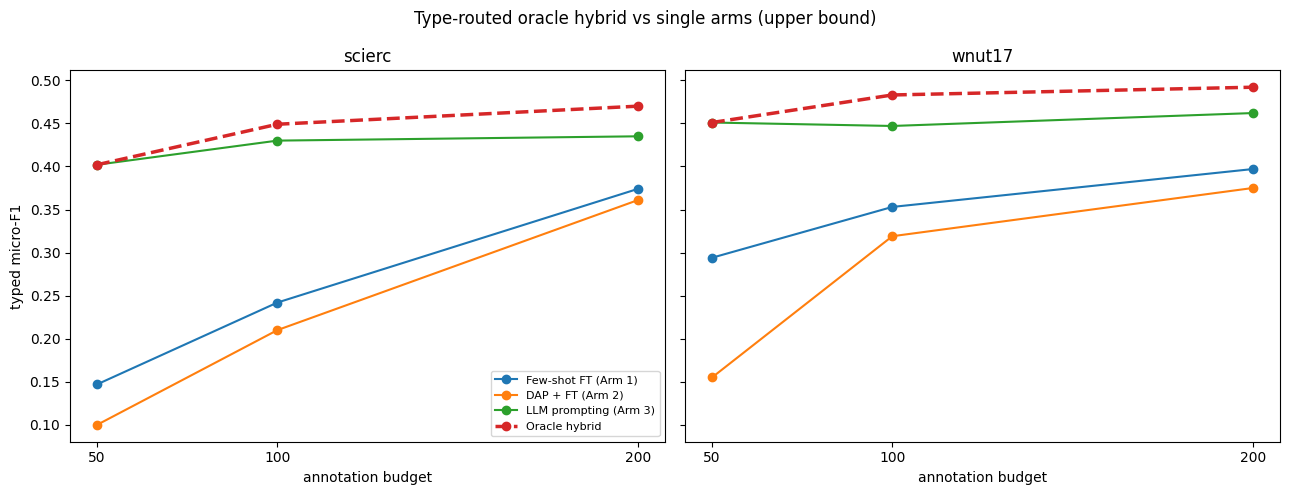

saved -> hybrid_oracle_by_budget.csv, hybrid_routing_by_type.csv, hybrid_oracle.png


In [6]:
fig, axes = plt.subplots(1, len(datasets), figsize=(6.5 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes = [axes]
plot_cols = arms + ['Oracle hybrid']
for ax, ds in zip(axes, datasets):
    sub = hybrid_df[hybrid_df['dataset'] == ds].sort_values('budget')
    for col in plot_cols:
        style = dict(marker='o', lw=2.5, ls='--') if col == 'Oracle hybrid' else dict(marker='o')
        ax.plot(sub['budget'], sub[col], label=col, **style)
    ax.set_title(ds); ax.set_xlabel('annotation budget'); ax.set_xticks(BUDGETS)
axes[0].set_ylabel('typed micro-F1'); axes[0].legend(fontsize=8)
fig.suptitle('Type-routed oracle hybrid vs single arms (upper bound)')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'hybrid_oracle.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> hybrid_oracle_by_budget.csv, hybrid_routing_by_type.csv, hybrid_oracle.png')

**Reading it:** the gap between the dashed "Oracle hybrid" line and the best single arm is the
head-room a per-type router could capture. A large gap motivates a deployable router (route by
model confidence / entity type), as in LinkNER; a small gap means the best single arm (the LLM,
here) is already close to the ceiling and a hybrid isn't worth the added complexity.